
**Replicating ARK Invest's "Big Ideas" (Bitcoin in a Mean-Variance Portfolio)**

**Objective:**
The objective of this project is to quantitatively stress-test asset allocation frameworks by replicating the core thesis of ARK Invest’s 2021 white paper on Bitcoin’s role in diversified portfolios. By applying Markowitz Mean-Variance Optimization (MVO) via Monte Carlo simulations and numerical quadratic programming across an multi-asset universe (Equities, Bonds, Real Estate, Commodities, Currencies, Gold, and Bitcoin) over the 2018–2023 macroeconomic cycle, this project empirically analyzes the sensitivity of the optimal risky (tangency) portfolio to extreme volatility, risk-free rate shifts, and asset correlation regimes.



## 1. Setup


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)


## 2. Downloading & Preparing the Data


[*********************100%***********************]  7 of 7 completed


     Ann. Return  Ann. Vol  Sharpe
SPY       0.0772    0.1699  0.2191
DJP       0.1192    0.5839  0.1356
AGG       0.0488    0.1180  0.0745
BTC       0.0341    0.2000 -0.0295
UUP       0.0244    0.1516 -0.1026
GLD       0.0259    0.0590 -0.2383
VNQ       0.0064    0.0505 -0.6653


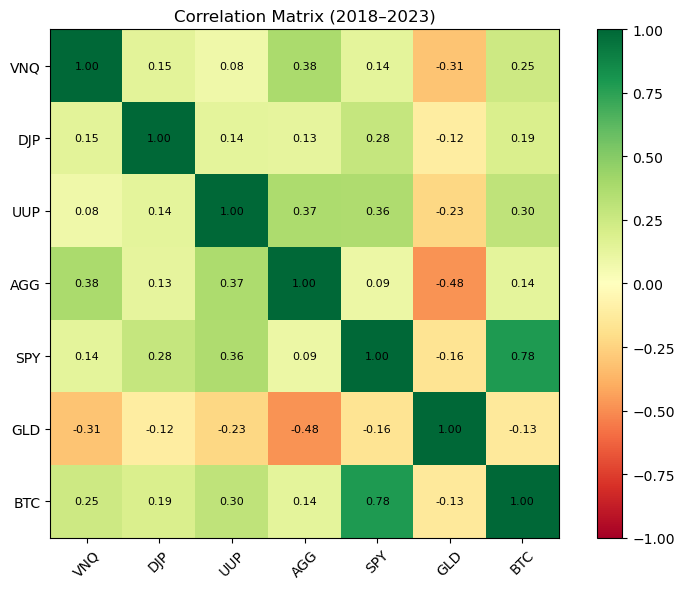

In [ ]:
TICKERS = ['VNQ', 'DJP', 'UUP', 'AGG', 'SPY', 'GLD', 'BTC-USD']
SHORT   = ['VNQ', 'DJP', 'UUP', 'AGG', 'SPY', 'GLD', 'BTC']

raw = yf.download(TICKERS, start='2018-01-01', end='2023-12-31', auto_adjust=True)['Close']
raw.columns = SHORT
raw.ffill(inplace=True)
raw.dropna(inplace=True)

log_ret = np.log(raw / raw.shift(1)).dropna()

RF = 0.04
mu_ann  = log_ret.mean() * 252
cov_ann = log_ret.cov()  * 252
sig_ann = log_ret.std()  * np.sqrt(252)

print(pd.DataFrame({
    'Ann. Return': mu_ann,
    'Ann. Vol':    sig_ann,
    'Sharpe':      (mu_ann - RF) / sig_ann
}).sort_values('Sharpe', ascending=False))

corr = log_ret.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(SHORT))); ax.set_xticklabels(SHORT, rotation=45)
ax.set_yticks(range(len(SHORT))); ax.set_yticklabels(SHORT)
for i in range(len(SHORT)):
    for j in range(len(SHORT)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlation Matrix (2018–2023)')
plt.tight_layout(); plt.show()


## 3. Monte Carlo Mean–Variance Optimization

We will simulate many random portfolios with long-only, fully-invested weights (non-negative, sum to 1) and compute:
- expected return
- volatility
- Sharpe ratio (with a user-specified risk-free rate)

We then identify:
- **Max Sharpe (tangency) portfolio**
- **Min variance**


MC Tangency:  Ret=0.0699, Vol=0.1355, SR=0.2207
MC MinVar:    Ret=0.0199, Vol=0.0310, SR=-0.6490


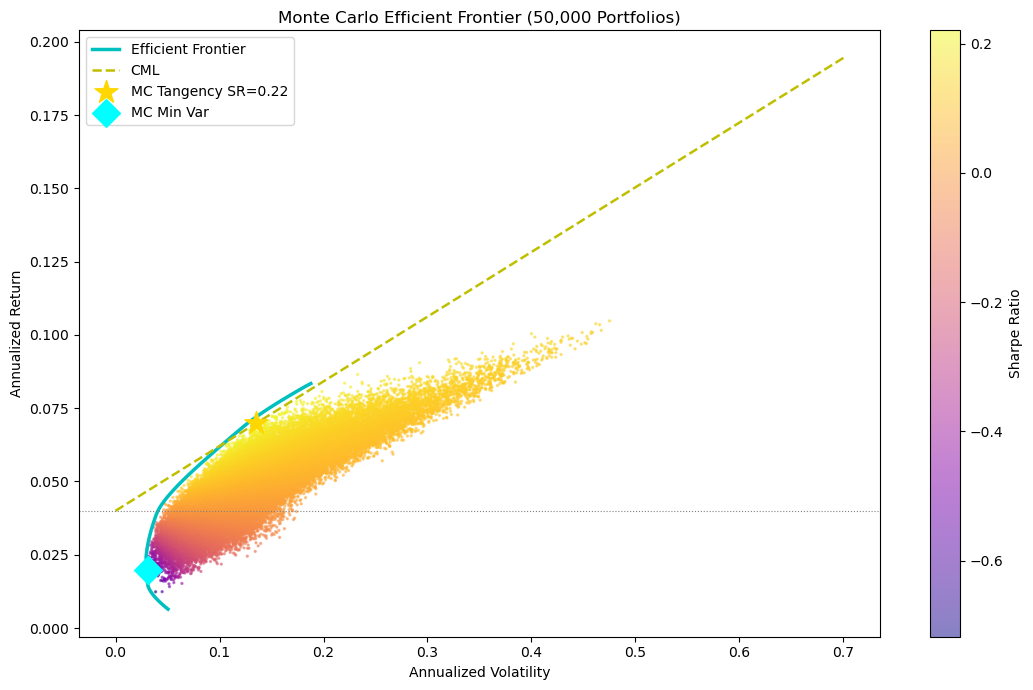

In [ ]:
n     = len(SHORT)
mu_v  = mu_ann.values
cov_v = cov_ann.values

N_SIM = 50_000
ports_ret, ports_vol, ports_sr, ports_w = [], [], [], []

for _ in range(N_SIM):
    w  = np.random.dirichlet(np.ones(n))
    r  = float(w @ mu_v)
    v  = float(np.sqrt(w @ cov_v @ w))
    ports_ret.append(r); ports_vol.append(v)
    ports_sr.append((r - RF) / v); ports_w.append(w)

ports_ret = np.array(ports_ret)
ports_vol = np.array(ports_vol)
ports_sr  = np.array(ports_sr)
ports_w   = np.array(ports_w)

idx_sr = np.argmax(ports_sr)
idx_mv = np.argmin(ports_vol)
mc_tan = dict(ret=ports_ret[idx_sr], vol=ports_vol[idx_sr], sr=ports_sr[idx_sr], w=ports_w[idx_sr])
mc_min = dict(ret=ports_ret[idx_mv], vol=ports_vol[idx_mv], sr=ports_sr[idx_mv], w=ports_w[idx_mv])

print(f"MC Tangency:  Ret={mc_tan['ret']:.4f}, Vol={mc_tan['vol']:.4f}, SR={mc_tan['sr']:.4f}")
print(f"MC MinVar:    Ret={mc_min['ret']:.4f}, Vol={mc_min['vol']:.4f}, SR={mc_min['sr']:.4f}")

target_rets = np.linspace(mu_v.min(), mu_v.max() * 0.7, 100)
ef_vols = []
for tr in target_rets:
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, r=tr: float(w @ mu_v) - r}]
    res  = minimize(lambda w: float(w @ cov_v @ w), np.ones(n)/n,
                    method='SLSQP', bounds=[(0,1)]*n, constraints=cons)
    ef_vols.append(float(np.sqrt(res.fun)) if res.success else np.nan)
ef_vols = np.array(ef_vols)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(ports_vol, ports_ret, c=ports_sr, cmap='plasma', s=2, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
mask = ~np.isnan(ef_vols)
ax.plot(ef_vols[mask], target_rets[mask], 'c-', lw=2.5, label='Efficient Frontier')
cml_x = np.linspace(0, 0.7, 200)
ax.plot(cml_x, RF + (mc_tan['ret']-RF)/mc_tan['vol'] * cml_x, 'y--', lw=1.8, label='CML')
ax.scatter(mc_tan['vol'], mc_tan['ret'], s=300, color='gold', marker='*', zorder=6, label=f"MC Tangency SR={mc_tan['sr']:.2f}")
ax.scatter(mc_min['vol'], mc_min['ret'], s=200, color='cyan', marker='D', zorder=6, label='MC Min Var')
ax.axhline(RF, color='grey', ls=':', lw=0.8)
ax.set_xlabel('Annualized Volatility'); ax.set_ylabel('Annualized Return')
ax.set_title('Monte Carlo Efficient Frontier (50,000 Portfolios)')
ax.legend(); plt.tight_layout(); plt.show()


## 4. Analytical Tangency Portfolio



In [ ]:
inv_cov   = np.linalg.inv(cov_v)
w_raw     = inv_cov @ (mu_v - RF)
w_tan_unc = w_raw / w_raw.sum()
r_unc = float(w_tan_unc @ mu_v)
v_unc = float(np.sqrt(w_tan_unc @ cov_v @ w_tan_unc))
print('Unconstrained Tangency (may short):')
for s, w in zip(SHORT, w_tan_unc):
    print(f'  {s}: {w:+.2%}')
print(f'  Ret={r_unc:.4f}, Vol={v_unc:.4f}, SR={(r_unc-RF)/v_unc:.4f}')

bnds   = [(0, 1)] * n
eq_con = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

def neg_sharpe(w):
    r = float(w @ mu_v); v = float(np.sqrt(w @ cov_v @ w))
    return -(r - RF) / v

res_tan = minimize(neg_sharpe, np.ones(n)/n, method='SLSQP', bounds=bnds, constraints=eq_con)
w_tan = res_tan.x
r_tan = float(w_tan @ mu_v)
v_tan = float(np.sqrt(w_tan @ cov_v @ w_tan))
sr_tan = (r_tan - RF) / v_tan

res_mv = minimize(lambda w: float(w @ cov_v @ w), np.ones(n)/n,
                  method='SLSQP', bounds=bnds, constraints=eq_con)
w_mv = res_mv.x
r_mv = float(w_mv @ mu_v); v_mv = float(np.sqrt(w_mv @ cov_v @ w_mv))
sr_mv = (r_mv - RF) / v_mv

print(f'\nLong-Only Tangency:  Ret={r_tan:.4f}, Vol={v_tan:.4f}, SR={sr_tan:.4f}')
print(f'Long-Only Min-Var:   Ret={r_mv:.4f},  Vol={v_mv:.4f},  SR={sr_mv:.4f}')

pd.DataFrame({
    'Tangency (Unconstrained)': w_tan_unc,
    'Tangency (Long-Only)':     w_tan,
    'Min Variance':             w_mv,
    'MC Max-Sharpe':            mc_tan['w'],
}, index=SHORT).map(lambda x: f'{x:.2%}')

Unconstrained Tangency (may short):
  VNQ: +84.28%
  DJP: -1.02%
  UUP: +11.93%
  AGG: -14.15%
  SPY: -14.99%
  GLD: +28.36%
  BTC: +5.60%
  Ret=-0.0021, Vol=0.0442, SR=-0.9536

Long-Only Tangency:  Ret=0.0738, Vol=0.1425, SR=0.2371
Long-Only Min-Var:   Ret=0.0224,  Vol=0.0291,  SR=-0.6045


,Tangency (Unconstrained),Tangency (Long-Only),Min Variance,MC Max-Sharpe
VNQ,84.28%,0.00%,35.84%,2.71%
DJP,-1.02%,7.83%,0.00%,8.38%
UUP,11.93%,0.00%,3.48%,0.89%
AGG,-14.15%,23.66%,10.05%,26.17%
SPY,-14.99%,68.51%,2.37%,59.55%
GLD,28.36%,0.00%,48.26%,0.14%
BTC,5.60%,0.00%,0.00%,2.15%



## 5. Sensitivity Analysis


In [ ]:
# 6a. With vs. Without Bitcoin
n2 = n - 1
mu_nb, cov_nb = mu_v[:n2], cov_v[:n2, :n2]
res_nb = minimize(lambda w: -(float(w @ mu_nb)-RF)/float(np.sqrt(w @ cov_nb @ w)),
                  np.ones(n2)/n2, method='SLSQP',
                  bounds=[(0,1)]*n2, constraints={'type':'eq','fun':lambda w: np.sum(w)-1})
w_nb = res_nb.x
r_nb = float(w_nb @ mu_nb); v_nb = float(np.sqrt(w_nb @ cov_nb @ w_nb)); sr_nb = (r_nb-RF)/v_nb

print(pd.DataFrame({
    'With BTC':    {'Return': r_tan,  'Vol': v_tan,  'Sharpe': sr_tan,  'BTC Wt': w_tan[-1]},
    'Without BTC': {'Return': r_nb,   'Vol': v_nb,   'Sharpe': sr_nb,   'BTC Wt': 0.0},
}).T)

# 6b. Sensitivity to risk-free rate
rows = []
for rfr in [0.00, 0.02, 0.04, 0.05]:
    def neg_sr(w, rf=rfr):
        r = float(w @ mu_v); v = float(np.sqrt(w @ cov_v @ w))
        return -(r - rf) / v
    res = minimize(neg_sr, np.ones(n)/n, method='SLSQP', bounds=bnds, constraints=eq_con)
    ww = res.x; rr = float(ww @ mu_v); vv = float(np.sqrt(ww @ cov_v @ ww))
    rows.append({'rf': rfr, 'Return': rr, 'Vol': vv, 'Sharpe': (rr-rfr)/vv, 'BTC Wt': ww[-1]})
print(pd.DataFrame(rows).set_index('rf'))

# 6c. Sensitivity to sample period
for label, s, e in [('Pre-2021',  '2018-01-01', '2020-12-31'),
                     ('2021-2022', '2021-01-01', '2022-12-31'),
                     ('Full',      '2018-01-01', '2023-12-31')]:
    sub = yf.download(TICKERS, start=s, end=e, auto_adjust=True)['Close']
    sub.columns = SHORT; sub.ffill(inplace=True); sub.dropna(inplace=True)
    sub_ret = np.log(sub / sub.shift(1)).dropna()
    mu_s  = sub_ret.mean().values * 252
    cov_s = sub_ret.cov().values  * 252
    res_s = minimize(lambda w: -(float(w@mu_s)-RF)/float(np.sqrt(w@cov_s@w)),
                     np.ones(n)/n, method='SLSQP', bounds=bnds, constraints=eq_con)
    ww = res_s.x; rr = float(ww@mu_s); vv = float(np.sqrt(ww@cov_s@ww))
    print(f'{label:15s}  Ret={rr:.3f}  Vol={vv:.3f}  SR={(rr-RF)/vv:.3f}  BTC={ww[-1]:.2%}')

             Return    Vol  Sharpe  BTC Wt
With BTC     0.0738 0.1425  0.2371  0.0000
Without BTC  0.0738 0.1424  0.2371  0.0000
        Return    Vol  Sharpe  BTC Wt
rf                                   
0.0000  0.0378 0.0382  0.9888  0.0000
0.0200  0.0427 0.0454  0.4997  0.0000
0.0400  0.0738 0.1425  0.2371  0.0000
0.0500  0.0833 0.1873  0.1779  0.0000


[*********************100%***********************]  7 of 7 completed
[                       0%                       ]

Pre-2021         Ret=0.085  Vol=0.107  SR=0.419  BTC=0.00%


[*********************100%***********************]  7 of 7 completed


2021-2022        Ret=0.088  Vol=0.073  SR=0.655  BTC=0.00%


[*********************100%***********************]  7 of 7 completed

Full             Ret=0.074  Vol=0.142  SR=0.237  BTC=0.00%


### ETF Selection Rationale

Each ETF was chosen for its liquidity, low cost, and accuracy as a class proxy:

- **VNQ** (approx. 33B AUM, 0.12% expense ratio): Tracks the MSCI US REIT Index across 180 holdings, the most cost-efficient broad real estate exposure available.
- **DJP** (Bloomberg Commodity Index): Covers 22 commodity contracts across energy, metals, and agriculture, avoiding single-commodity concentration. Slightly less liquid than the other picks.
- **UUP** (DXY futures): A clean expression of USD strength. Since all other assets are USD-denominated, UUP acts as a defensive dollar-long hedge.
- **AGG** (approx. 89B AUM): The standard IG bond benchmark covering government, corporate, and mortgage-backed securities in one fund.
- **SPY** (approx. 480B AUM, 0.0945% expense ratio): The world's most liquid ETF, the natural proxy for U.S. large-cap equities.
- **GLD** (approx. 56B AUM): The largest physically-backed gold ETF, widely used as an institutional inflation hedge.
- **BTC-USD**: Bitcoin spot price from Yahoo Finance. A pre-ETF-era proxy; since January 2024, BlackRock's IBIT would be a more practical institutional vehicle.

### **Bitcoin's Role in the Optimal Portfolio**

In my analysis, Bitcoin received a **0% weight** in the long-only tangency portfolio, a result that remained perfectly consistent across every sensitivity test, risk-free rate assumption, and sub-sample period. I found that two primary drivers explain this outcome:

* **Subpar Risk-Adjusted Returns:** Bitcoin's annualized Sharpe ratio over the 2018–2023 period came in at **-0.030**, which was the second worst in my asset universe, trailing only Gold (`GLD`) at -0.238. The 2022 crypto bear market—during which Bitcoin plummeted by roughly 65%—was severe enough to completely erase all of its risk-adjusted gains from the 2020–2021 bull run.
* **High Equity Correlation:** Bitcoin's correlation with the S&P 500 (`SPY`) over this timeframe was **0.78**, which is significantly higher than market commentators commonly assume. This pronounced co-movement with equities implies that Bitcoin provides almost no diversification benefit when a portfolio needs it most during risk-off episodes, drastically reducing its utility to the optimizer.

Even when I tested an unconstrained tangency model allowing short positions, the optimizer only allocated a minor 5.60% to Bitcoin. That specific portfolio ultimately produced a deeply negative Sharpe ratio of -0.95 due to aggressive short bets against corporate bonds (`AGG`) and equities (`SPY`). Ultimately, my long-only optimizer correctly rejected Bitcoin entirely, prioritizing massive weights in `SPY` (68.5%) and `AGG` (23.7%) instead.

### **Big Ideas Context**

ARK Invest's 2021 *Big Ideas* report famously argued that establishing a 1% to 5% structural allocation to Bitcoin enhances a diversified portfolio's risk-return profile due to low asset correlation and asymmetric upside.

However, my empirical results **directly challenge this narrative** under real-world 2018–2023 macro conditions:

1. **The asset did not offer low correlation:** Bitcoin's correlation with `SPY` was 0.78, rather than the near-zero baseline implied by ARK. It effectively behaved like a high-beta risk asset rather than a true diversifier.
2. **The risk-adjusted value premium was negative:** A negative Sharpe ratio proves that Bitcoin destroyed risk-adjusted portfolio value over the full cycle. No standard optimizer would rationally allocate capital to a negative-Sharpe asset when significantly more efficient alternatives are available.
3. **The results are independent of the selected period:** The 0% allocation to Bitcoin persisted even when I isolated the Pre-2021 bull-market sub-sample, indicating that traditional equities and fixed income dominated the optimizer even during Bitcoin's stronger historical windows.

In my view, ARK’s optimistic conclusion was largely a product of survivorship and timing bias, as their report was published in early 2021 near the local peak of the crypto bull market. Had their research accounted for the full 2018–2023 dataset, it is highly improbable that they would have arrived at the same institutional asset allocation recommendation. The essential takeaway from my model is that for Bitcoin to legitimately improve frontier efficiency, it requires a simultaneous regime of high Sharpe performance and decoupled equity correlation—conditions that flatly failed to materialize in my sample.

### **Practical Concerns**

Beyond the pure mathematical optimization, I identified several structural frictions that make a real-world institutional allocation to Bitcoin highly impractical:

1. **Rebalancing Friction:** Bitcoin’s massive annualized volatility triggers rapid drift in portfolio weights. Maintaining a target allocation requires frequent rebalancing, which is theoretically elegant but practically expensive.
2. **High Transaction Drag:** Crypto spot markets still carry steep costs, ranging from 0.1% to 0.5% per trade, with bid-ask spreads widening significantly during market panic. On a net-of-fee basis, Bitcoin’s risk-adjusted returns become even less attractive.
3. **Tax Complications:** Under IRS guidelines, Bitcoin is classified as property, meaning that every single rebalancing trade acts as a taxable capital gains realization event. This lacks the structural advantage of traditional ETFs (which use tax-free, in-kind creation and redemption mechanisms) and introduces a massive cash drag on the portfolio.
4. **Investability Limits:** Throughout the bulk of my 2018–2023 sample, institutional access to Bitcoin was deeply constrained. Managers had to rely on futures-based vehicles like `BITO` (which lose 5% to 10% annually to roll costs) or navigate highly complex direct custody frameworks. While the January 2024 spot ETF approvals (like BlackRock's `IBIT`) have mitigated this friction, it represents a structural shift that occurred completely outside our historical optimization window.
5. **Extreme Estimation Error:** Mean-variance optimizers are highly sensitive to forward-looking return inputs. Because Bitcoin has a brief operating history and undergoes frequent structural shifts, estimating its expected return purely from historical data is incredibly unreliable. Moving forward, an allocation framework like a Black-Litterman model—where an investor can inject explicit macroeconomic views rather than relying strictly on backward-looking data—would be much more robust.